In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample, class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc

# Import model
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE


✅ CuPy detected - Using GPU acceleration


In [2]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✅ CuPy detected - Using GPU acceleration")
    use_gpu = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False
    print("⚠️ CuPy not found - Falling back to NumPy (CPU)")
    use_gpu = False

✅ CuPy detected - Using GPU acceleration


In [ ]:
# === 2. Preprocess Data ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

In [4]:
# === 3. Base Functions/Procedures ===
# === 3.1 Windowing Function ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)

        

In [5]:
# === 4. Training ===
def train_eval(X, y, label, cw=1, hidden_size=128, patience=10, epochs=100, batch_size=128, lr=0.005, print_every=1, lambda_l2=0.001):
    """
    Train and evaluate LSTM model with proper train/validation split
    
    Args:
        X: Input sequences
        y: Labels
        label: Experiment label
        cw: Class weight for minority class (default=1, no weighting)
        hidden_size: LSTM hidden units
        patience: Early stopping patience
        epochs: Max training epochs
        batch_size: Batch size
        lr: Learning rate
        print_every: Print frequency
        lambda_l2: L2 regularization strength
    """
    # Split: 60% train, 20% val, 20% test
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)
    
    input_size = X.shape[2]  # Auto-detect from data shape

    # Initialize Model with class weight
    model = LSTMModelGPUOptimized(input_size=input_size, hidden_size=hidden_size, cw=cw)
    start_time = time.time()
    
    history = model.train(
        X_tr, y_tr,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=print_every,
        patience=patience,
        lambda_l2=lambda_l2
    )
    duration = time.time() - start_time
    
    # Evaluate on test set
    y_prob = model.predict(X_te, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    y_pred = (y_prob >= 0.5).astype(int)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Calculate metrics
    return {
        'Model': label,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': auc_score,
        'TrainingTime': duration,
        'TrainableParams': model.count_params() if hasattr(model, 'count_params') else 0,
        'ClassWeight': cw
    }



Sampling Period: 30min

  Window Size: 12
    Data: 14628 samples, Class 0: 10137, Class 1: 4491
    → Running Undersampling...
Training: 5388 samples, 43 batches/epoch, batch_size=128
Validation: 1797 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6131 | Val Loss: 0.5912 | Val Acc: 0.6450 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5880 | Val Loss: 0.5949 | Val Acc: 0.6361 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5899 | Val Loss: 0.5939 | Val Acc: 0.6338 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5853 | Val Loss: 0.5903 | Val Acc: 0.6533 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5850 | Val Loss: 0.5902 | Val Acc: 0.6361 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5845 | Val Loss: 0.5893 | Val Acc: 0.6333 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5829 | Val Loss: 0.5839 | Val Acc: 0.6355 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5834 | Val Loss: 0.5827 | Val Acc: 0.6411

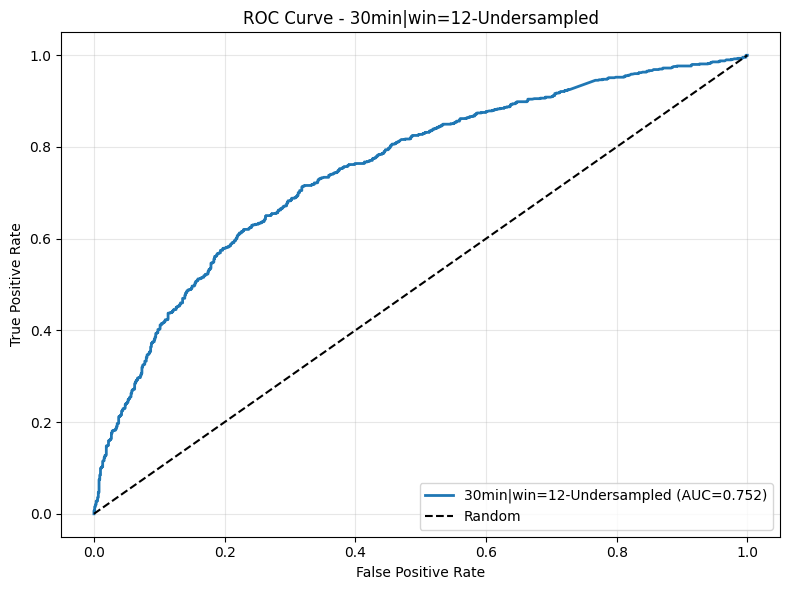

    → Running SMOTE...
Training: 12164 samples, 96 batches/epoch, batch_size=128
Validation: 4055 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.5991 | Val Loss: 0.5839 | Val Acc: 0.6982 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5875 | Val Loss: 0.5787 | Val Acc: 0.6451 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5782 | Val Loss: 0.5747 | Val Acc: 0.6819 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5729 | Val Loss: 0.5671 | Val Acc: 0.6895 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5734 | Val Loss: 0.5654 | Val Acc: 0.6607 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5703 | Val Loss: 0.5668 | Val Acc: 0.6764 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5704 | Val Loss: 0.5670 | Val Acc: 0.6910 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5681 | Val Loss: 0.5640 | Val Acc: 0.6912 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5697 | Val Loss: 0.5643 | Val Acc: 0.6912 [UNDERFITTING]
E

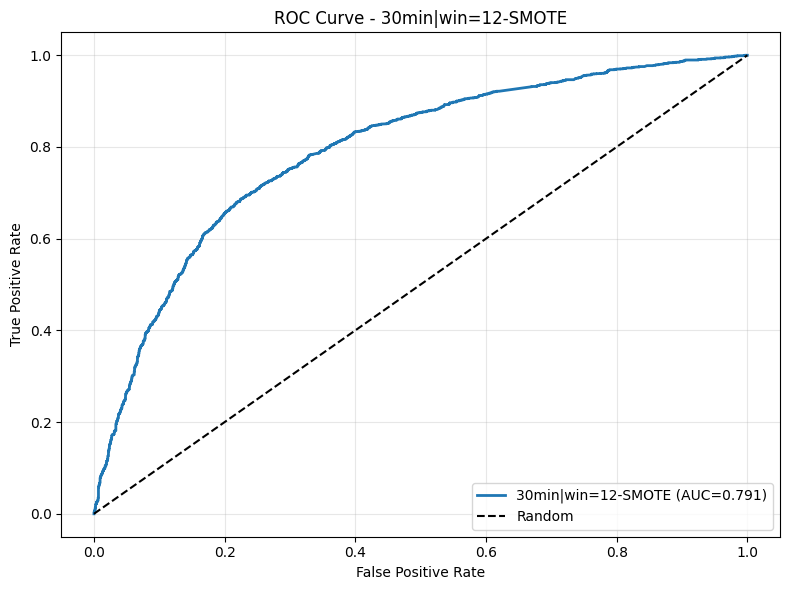

    → Running with Class Weight: 2.26x for minority class
Training: 8776 samples, 69 batches/epoch, batch_size=128
Validation: 2926 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6253 | Val Loss: 0.6224 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5967 | Val Loss: 0.5688 | Val Acc: 0.5817 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5989 | Val Loss: 0.5948 | Val Acc: 0.5352 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5951 | Val Loss: 0.5990 | Val Acc: 0.5526 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5910 | Val Loss: 0.5927 | Val Acc: 0.5793 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5911 | Val Loss: 0.5727 | Val Acc: 0.5612 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5854 | Val Loss: 0.5856 | Val Acc: 0.5560 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5890 | Val Loss: 0.6100 | Val Acc: 0.5602 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5866 | Val Loss: 0.5953 

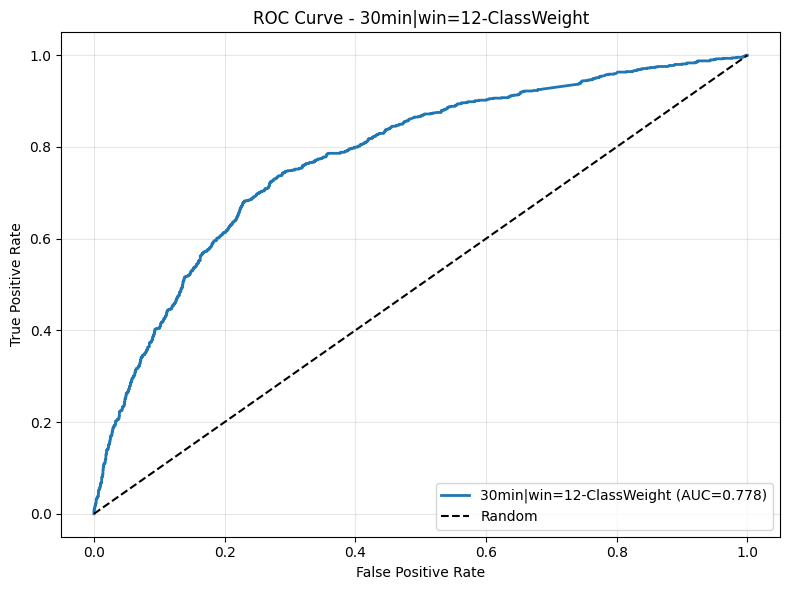


  Window Size: 24
    Data: 14616 samples, Class 0: 10130, Class 1: 4486
    → Running Undersampling...
Training: 5382 samples, 43 batches/epoch, batch_size=128
Validation: 1795 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6090 | Val Loss: 0.5958 | Val Acc: 0.5894 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5961 | Val Loss: 0.5816 | Val Acc: 0.6407 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5858 | Val Loss: 0.5769 | Val Acc: 0.6318 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5855 | Val Loss: 0.5729 | Val Acc: 0.6479 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5822 | Val Loss: 0.5798 | Val Acc: 0.6474 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5852 | Val Loss: 0.5751 | Val Acc: 0.6396 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5867 | Val Loss: 0.5677 | Val Acc: 0.6496 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5811 | Val Loss: 0.5831 | Val Acc: 0.6418 [UNDERFITTING]
Epoch   

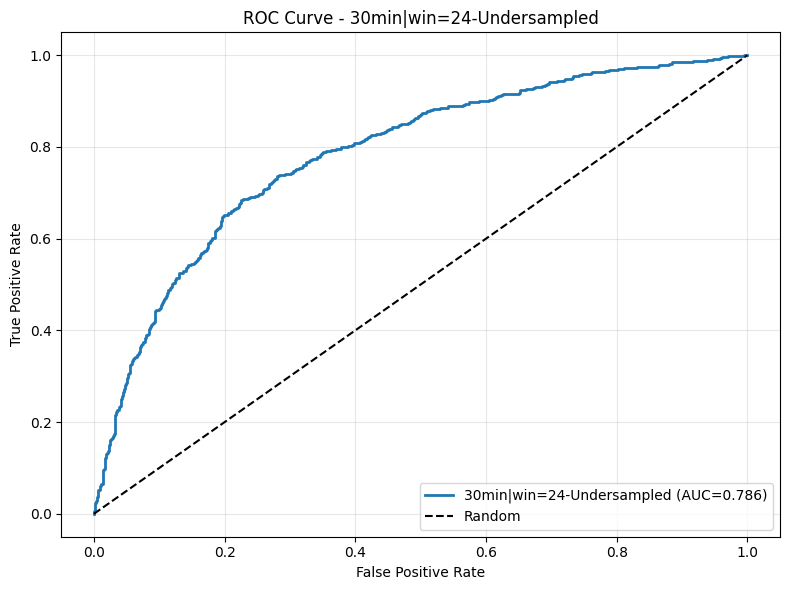

    → Running SMOTE...
Training: 12156 samples, 95 batches/epoch, batch_size=128
Validation: 4052 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.5971 | Val Loss: 0.5625 | Val Acc: 0.6883 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5723 | Val Loss: 0.5643 | Val Acc: 0.6456 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5649 | Val Loss: 0.5724 | Val Acc: 0.6903 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5583 | Val Loss: 0.5549 | Val Acc: 0.6614 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5558 | Val Loss: 0.5515 | Val Acc: 0.6752 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5516 | Val Loss: 0.5473 | Val Acc: 0.6725 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5528 | Val Loss: 0.5388 | Val Acc: 0.7103 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5496 | Val Loss: 0.5432 | Val Acc: 0.7261 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5466 | Val Loss: 0.5414 | Val Acc: 0.6881 [UNDERFITTING]
E

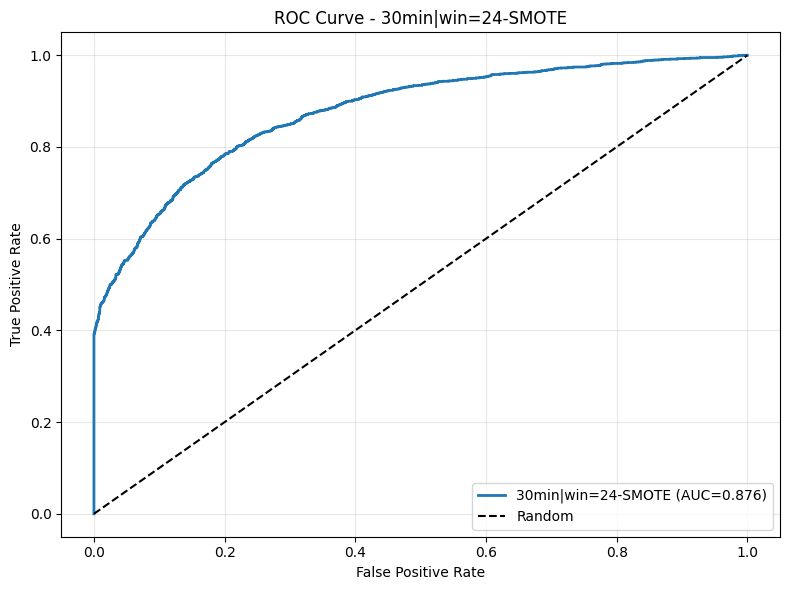

    → Running with Class Weight: 2.26x for minority class
Training: 8769 samples, 69 batches/epoch, batch_size=128
Validation: 2923 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6066 | Val Loss: 0.6220 | Val Acc: 0.4174 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5751 | Val Loss: 0.5987 | Val Acc: 0.5594 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5693 | Val Loss: 0.6126 | Val Acc: 0.5932 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5677 | Val Loss: 0.5747 | Val Acc: 0.5813 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5657 | Val Loss: 0.5648 | Val Acc: 0.6220 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5643 | Val Loss: 0.5668 | Val Acc: 0.6045 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5645 | Val Loss: 0.6012 | Val Acc: 0.5765 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5572 | Val Loss: 0.5907 | Val Acc: 0.5566 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5611 | Val Loss: 0.6003 

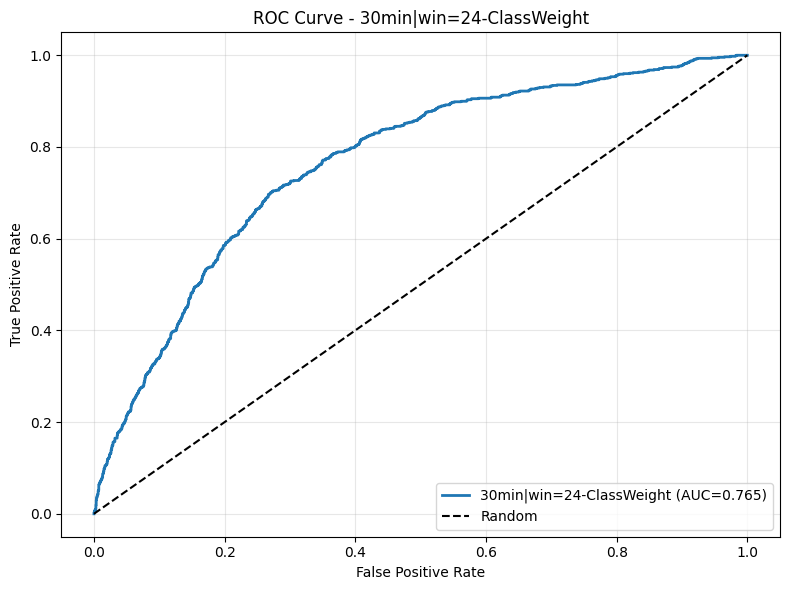


  Window Size: 36
    Data: 14604 samples, Class 0: 10122, Class 1: 4482
    → Running Undersampling...
Training: 5378 samples, 43 batches/epoch, batch_size=128
Validation: 1793 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6008 | Val Loss: 0.6096 | Val Acc: 0.6129 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6030 | Val Loss: 0.5904 | Val Acc: 0.6631 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5868 | Val Loss: 0.6002 | Val Acc: 0.6252 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5970 | Val Loss: 0.5881 | Val Acc: 0.6347 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5848 | Val Loss: 0.5835 | Val Acc: 0.6670 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5888 | Val Loss: 0.5870 | Val Acc: 0.6514 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5756 | Val Loss: 0.5883 | Val Acc: 0.6910 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5737 | Val Loss: 0.5862 | Val Acc: 0.6397 [UNDERFITTING]
Epoch   

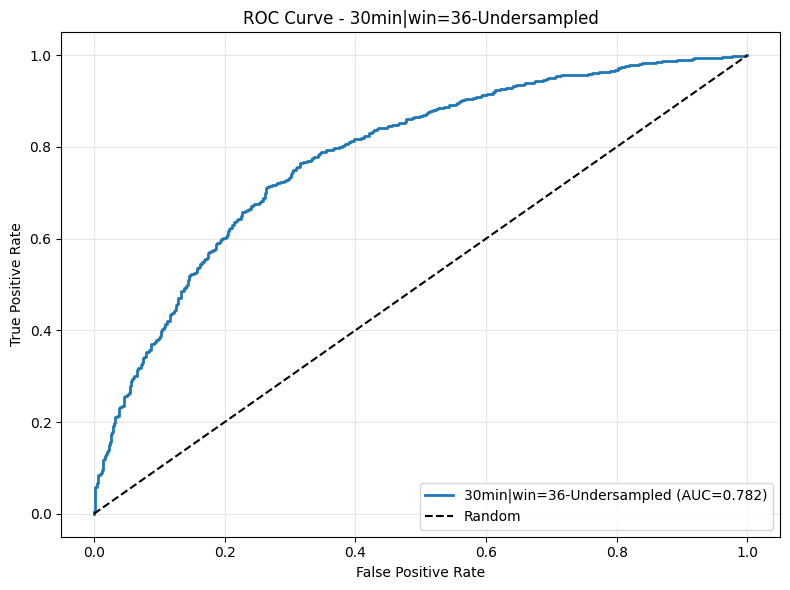

    → Running SMOTE...
Training: 12146 samples, 95 batches/epoch, batch_size=128
Validation: 4049 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.5889 | Val Loss: 0.5759 | Val Acc: 0.6814 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5655 | Val Loss: 0.5752 | Val Acc: 0.6493 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5561 | Val Loss: 0.5672 | Val Acc: 0.6952 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5549 | Val Loss: 0.5591 | Val Acc: 0.6888 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5513 | Val Loss: 0.5566 | Val Acc: 0.7009 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5507 | Val Loss: 0.5539 | Val Acc: 0.6940 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5464 | Val Loss: 0.5487 | Val Acc: 0.7068 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5433 | Val Loss: 0.5530 | Val Acc: 0.6718 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5361 | Val Loss: 0.5348 | Val Acc: 0.6898 [UNDERFITTING]
E

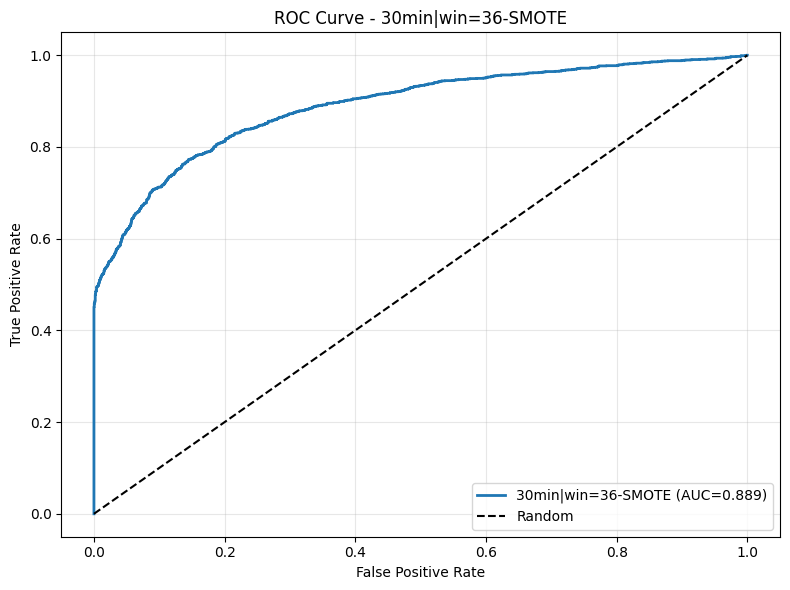

    → Running with Class Weight: 2.26x for minority class
Training: 8762 samples, 69 batches/epoch, batch_size=128
Validation: 2921 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6125 | Val Loss: 0.6252 | Val Acc: 0.5505 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5909 | Val Loss: 0.6349 | Val Acc: 0.5228 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5846 | Val Loss: 0.5542 | Val Acc: 0.6084 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5825 | Val Loss: 0.5489 | Val Acc: 0.6330 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5800 | Val Loss: 0.5481 | Val Acc: 0.6128 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5821 | Val Loss: 0.5577 | Val Acc: 0.6005 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5705 | Val Loss: 0.5651 | Val Acc: 0.5957 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5742 | Val Loss: 0.5530 | Val Acc: 0.5984 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5762 | Val Loss: 0.5557 

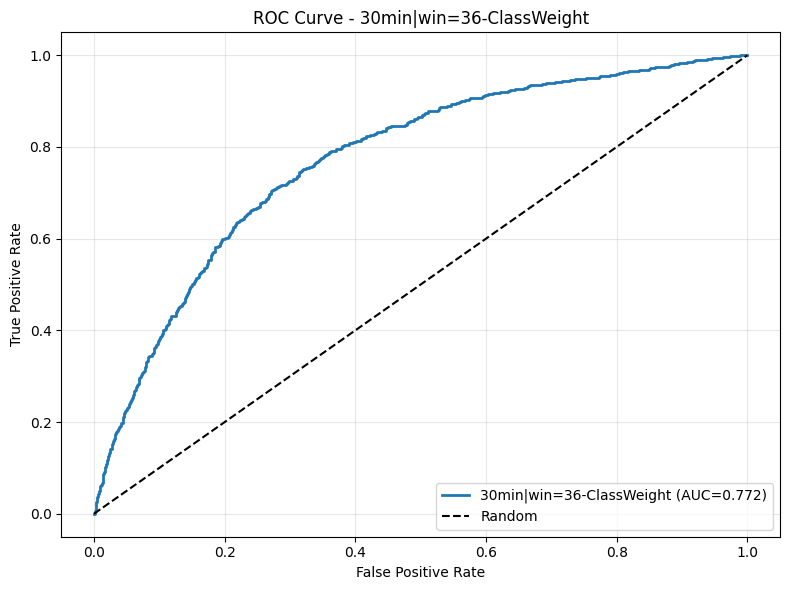


  Window Size: 48
    Data: 14592 samples, Class 0: 10112, Class 1: 4480
    → Running Undersampling...
Training: 5376 samples, 42 batches/epoch, batch_size=128
Validation: 1792 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6067 | Val Loss: 0.5889 | Val Acc: 0.6964 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5947 | Val Loss: 0.5772 | Val Acc: 0.6328 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5907 | Val Loss: 0.5770 | Val Acc: 0.7037 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5899 | Val Loss: 0.5733 | Val Acc: 0.6674 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5848 | Val Loss: 0.5680 | Val Acc: 0.6401 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5839 | Val Loss: 0.5678 | Val Acc: 0.6680 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5794 | Val Loss: 0.5700 | Val Acc: 0.6272 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5768 | Val Loss: 0.5581 | Val Acc: 0.6908 [UNDERFITTING]
Epoch   

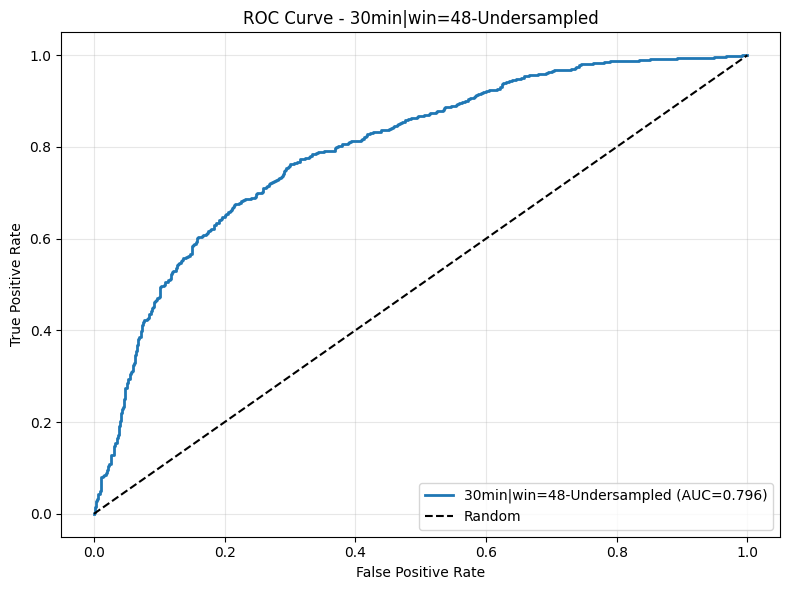

    → Running SMOTE...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.5915 | Val Loss: 0.5693 | Val Acc: 0.7036 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5713 | Val Loss: 0.5495 | Val Acc: 0.6883 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5607 | Val Loss: 0.5420 | Val Acc: 0.6925 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5541 | Val Loss: 0.5403 | Val Acc: 0.6934 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5343 | Val Loss: 0.4990 | Val Acc: 0.7152
Epoch    6/100 | Train Loss: 0.4972 | Val Loss: 0.4667 | Val Acc: 0.7352
Epoch    7/100 | Train Loss: 0.4647 | Val Loss: 0.4437 | Val Acc: 0.7614
Epoch    8/100 | Train Loss: 0.4384 | Val Loss: 0.4273 | Val Acc: 0.7659
Epoch    9/100 | Train Loss: 0.4233 | Val Loss: 0.4166 | Val Acc: 0.7896
Epoch   10/100 | Train Loss: 0.4150 | Val Loss: 0.4046 | Val Acc: 0.7904
Epo

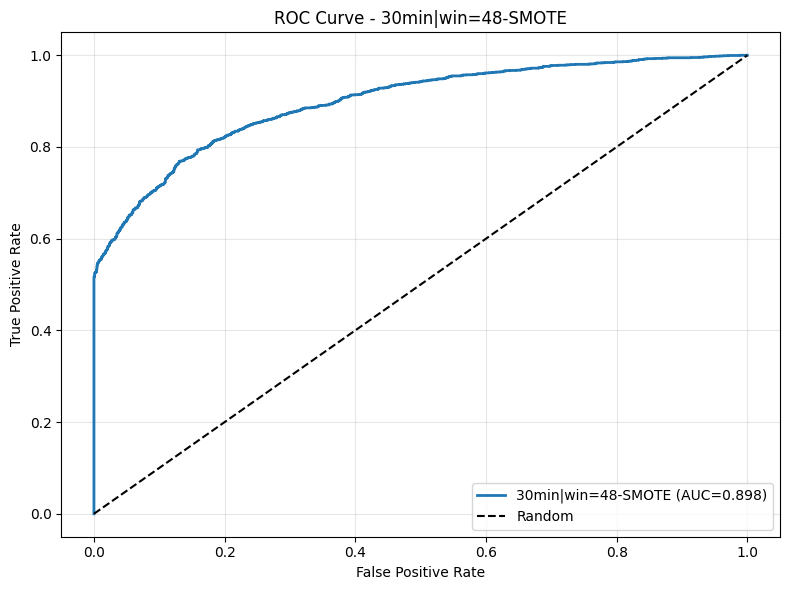

    → Running with Class Weight: 2.26x for minority class
Training: 8754 samples, 69 batches/epoch, batch_size=128
Validation: 2919 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6165 | Val Loss: 0.5679 | Val Acc: 0.5807 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5838 | Val Loss: 0.5822 | Val Acc: 0.5588 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5791 | Val Loss: 0.5630 | Val Acc: 0.6290 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5764 | Val Loss: 0.6067 | Val Acc: 0.5190 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5734 | Val Loss: 0.5665 | Val Acc: 0.5749 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5702 | Val Loss: 0.5771 | Val Acc: 0.5457 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5710 | Val Loss: 0.5267 | Val Acc: 0.6461 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5720 | Val Loss: 0.5452 | Val Acc: 0.6180 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5674 | Val Loss: 0.5448 

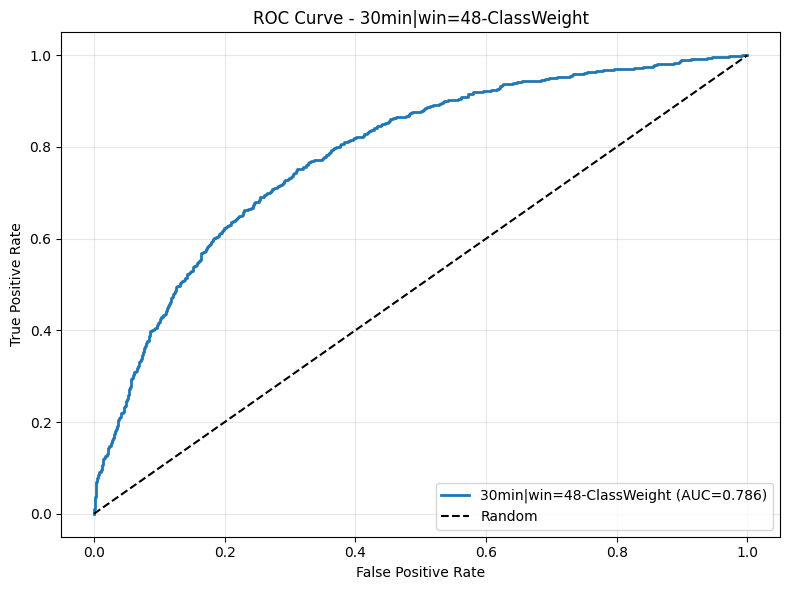


Sampling Period: 1h

  Window Size: 12
    Data: 7309 samples, Class 0: 3988, Class 1: 3321
    → Running Undersampling...
Training: 3984 samples, 32 batches/epoch, batch_size=128
Validation: 1329 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6254 | Val Loss: 0.6041 | Val Acc: 0.6682 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.6080 | Val Loss: 0.5990 | Val Acc: 0.6388 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5864 | Val Loss: 0.5924 | Val Acc: 0.6591 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5825 | Val Loss: 0.6018 | Val Acc: 0.5892 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5791 | Val Loss: 0.5926 | Val Acc: 0.6599 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5845 | Val Loss: 0.5870 | Val Acc: 0.6591 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5723 | Val Loss: 0.5846 | Val Acc: 0.6471 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5658 | Val Loss: 0.5829 | Val Acc: 0.6674 [UND

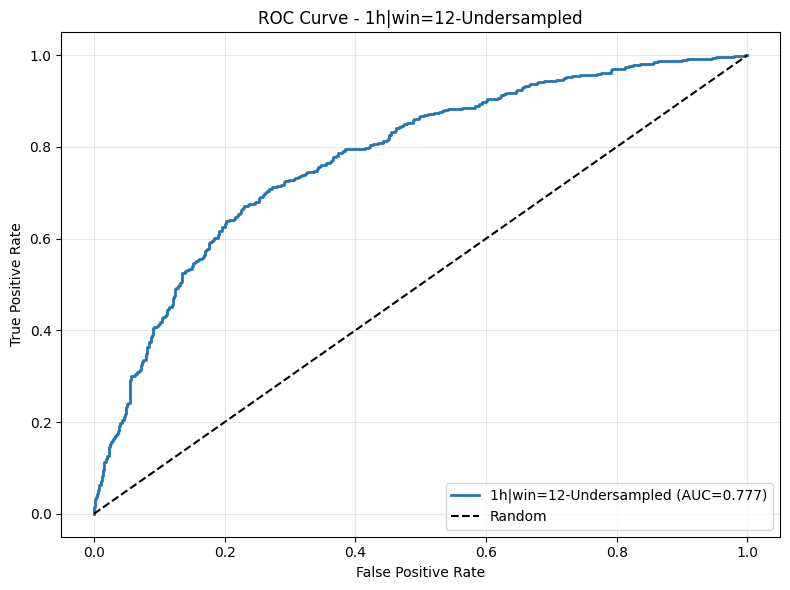

    → Running SMOTE...
Training: 4785 samples, 38 batches/epoch, batch_size=128
Validation: 1595 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6129 | Val Loss: 0.6088 | Val Acc: 0.5774 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5951 | Val Loss: 0.6009 | Val Acc: 0.6232 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5859 | Val Loss: 0.5929 | Val Acc: 0.6251 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5807 | Val Loss: 0.5896 | Val Acc: 0.6414 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5783 | Val Loss: 0.5867 | Val Acc: 0.6395 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5745 | Val Loss: 0.5822 | Val Acc: 0.6665 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5726 | Val Loss: 0.5815 | Val Acc: 0.6683 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5709 | Val Loss: 0.5853 | Val Acc: 0.6734 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5708 | Val Loss: 0.5804 | Val Acc: 0.6721 [UNDERFITTING]
Ep

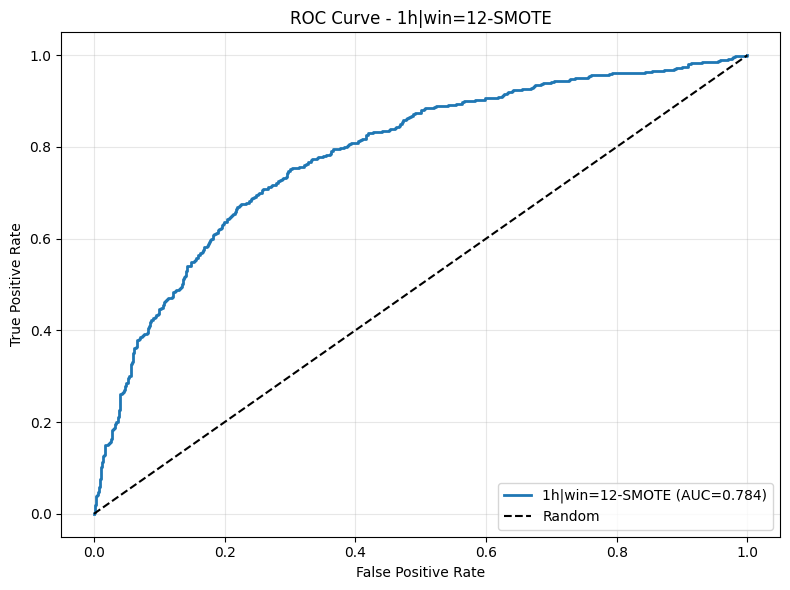

    → Running with Class Weight: 1.20x for minority class
Training: 4385 samples, 35 batches/epoch, batch_size=128
Validation: 1462 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6280 | Val Loss: 0.6324 | Val Acc: 0.4726 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5973 | Val Loss: 0.5955 | Val Acc: 0.5958 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5902 | Val Loss: 0.5985 | Val Acc: 0.5622 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5891 | Val Loss: 0.5771 | Val Acc: 0.6389 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5804 | Val Loss: 0.5803 | Val Acc: 0.5800 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5874 | Val Loss: 0.5866 | Val Acc: 0.6005 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5789 | Val Loss: 0.5788 | Val Acc: 0.6621 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5826 | Val Loss: 0.5693 | Val Acc: 0.6402 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5738 | Val Loss: 0.5677 

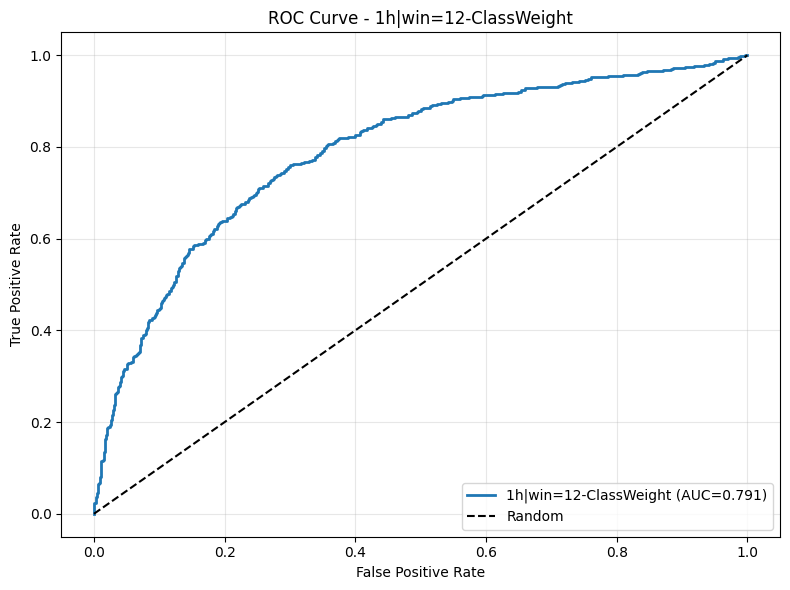


  Window Size: 24
    Data: 7297 samples, Class 0: 3981, Class 1: 3316
    → Running Undersampling...
Training: 3978 samples, 32 batches/epoch, batch_size=128
Validation: 1327 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6200 | Val Loss: 0.6476 | Val Acc: 0.6790 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5951 | Val Loss: 0.5811 | Val Acc: 0.6503 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5750 | Val Loss: 0.5817 | Val Acc: 0.6534 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5745 | Val Loss: 0.5707 | Val Acc: 0.6541 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5779 | Val Loss: 0.5742 | Val Acc: 0.6534 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5602 | Val Loss: 0.5531 | Val Acc: 0.6971 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5532 | Val Loss: 0.5491 | Val Acc: 0.7038 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5636 | Val Loss: 0.5561 | Val Acc: 0.7061 [UNDERFITTING]
Epoch    9

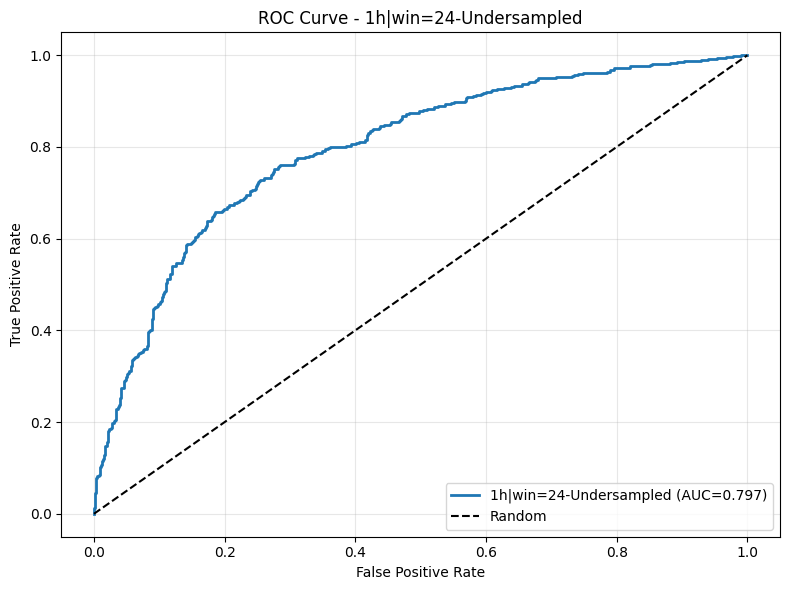

    → Running SMOTE...
Training: 4776 samples, 38 batches/epoch, batch_size=128
Validation: 1593 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6035 | Val Loss: 0.5841 | Val Acc: 0.6378 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5797 | Val Loss: 0.5818 | Val Acc: 0.6623 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5620 | Val Loss: 0.5780 | Val Acc: 0.6723 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5590 | Val Loss: 0.5661 | Val Acc: 0.6491 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5476 | Val Loss: 0.5640 | Val Acc: 0.6704 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5425 | Val Loss: 0.5735 | Val Acc: 0.6868 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5395 | Val Loss: 0.5648 | Val Acc: 0.6660 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5452 | Val Loss: 0.5648 | Val Acc: 0.6780 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5404 | Val Loss: 0.5689 | Val Acc: 0.6893 [UNDERFITTING]
Ep

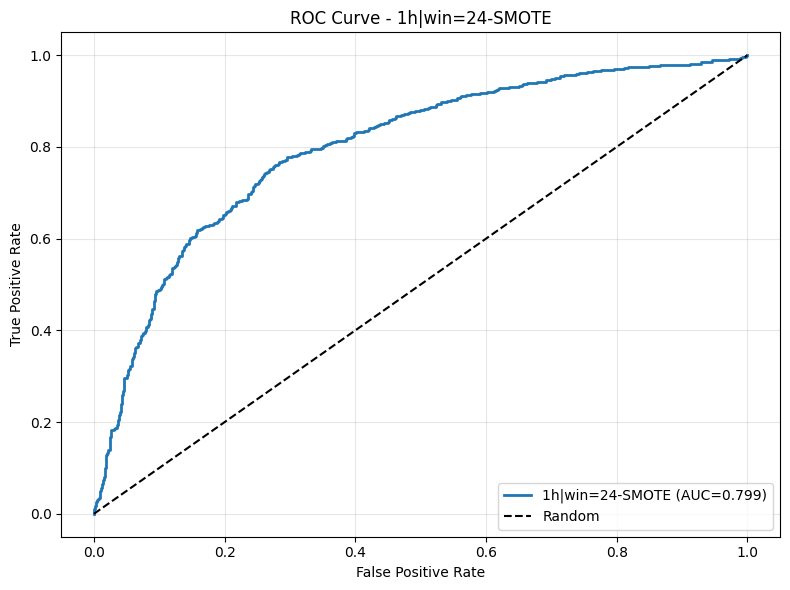

    → Running with Class Weight: 1.20x for minority class
Training: 4377 samples, 35 batches/epoch, batch_size=128
Validation: 1460 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6121 | Val Loss: 0.5826 | Val Acc: 0.6603 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5771 | Val Loss: 0.6002 | Val Acc: 0.5301 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5703 | Val Loss: 0.5693 | Val Acc: 0.6397 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5653 | Val Loss: 0.5560 | Val Acc: 0.6514 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5582 | Val Loss: 0.5754 | Val Acc: 0.6247 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5640 | Val Loss: 0.5606 | Val Acc: 0.6637 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5548 | Val Loss: 0.5430 | Val Acc: 0.6788 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5442 | Val Loss: 0.5473 | Val Acc: 0.6788 [UNDERFITTING]
Epoch    9/100 | Train Loss: 0.5568 | Val Loss: 0.5450 

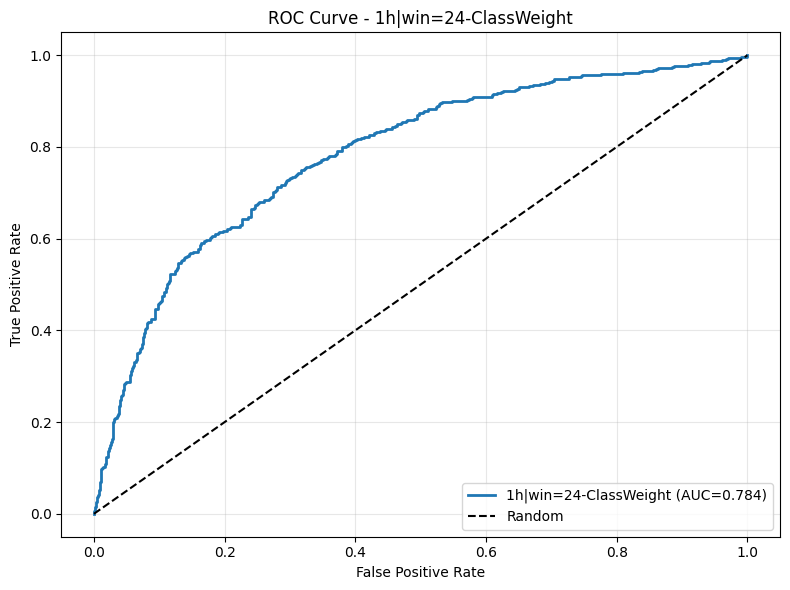


  Window Size: 36
    Data: 7285 samples, Class 0: 3973, Class 1: 3312
    → Running Undersampling...
Training: 3974 samples, 32 batches/epoch, batch_size=128
Validation: 1325 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6102 | Val Loss: 0.5818 | Val Acc: 0.6204 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5689 | Val Loss: 0.5659 | Val Acc: 0.6536 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5634 | Val Loss: 0.5640 | Val Acc: 0.6717 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5702 | Val Loss: 0.5716 | Val Acc: 0.6566 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5622 | Val Loss: 0.5598 | Val Acc: 0.6551 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5634 | Val Loss: 0.5595 | Val Acc: 0.6574 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5504 | Val Loss: 0.5512 | Val Acc: 0.6936 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5618 | Val Loss: 0.5663 | Val Acc: 0.6475 [UNDERFITTING]
Epoch    9

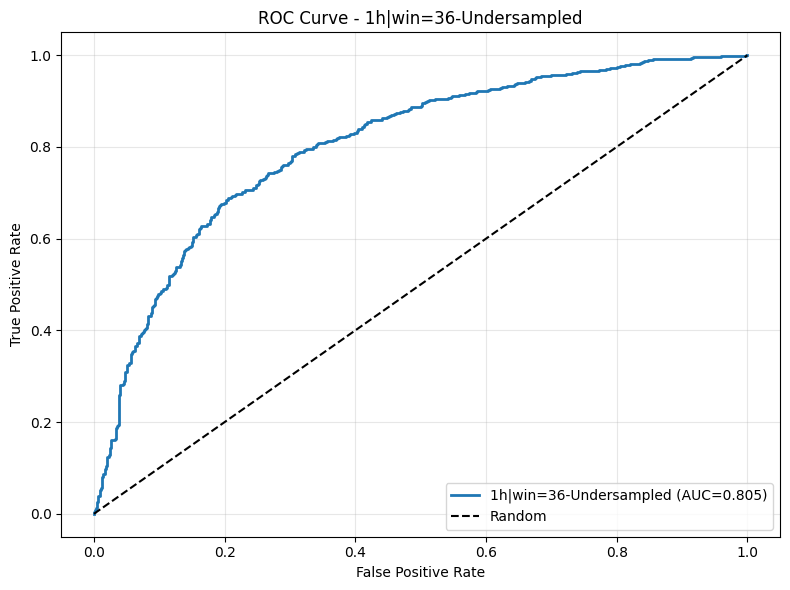

    → Running SMOTE...
Training: 4767 samples, 38 batches/epoch, batch_size=128
Validation: 1589 samples | Early stopping patience: 10
----------------------------------------------------------------------
Epoch    1/100 | Train Loss: 0.6163 | Val Loss: 0.5652 | Val Acc: 0.7149 [UNDERFITTING]
Epoch    2/100 | Train Loss: 0.5702 | Val Loss: 0.5633 | Val Acc: 0.7017 [UNDERFITTING]
Epoch    3/100 | Train Loss: 0.5603 | Val Loss: 0.5562 | Val Acc: 0.6809 [UNDERFITTING]
Epoch    4/100 | Train Loss: 0.5616 | Val Loss: 0.5627 | Val Acc: 0.7011 [UNDERFITTING]
Epoch    5/100 | Train Loss: 0.5597 | Val Loss: 0.5510 | Val Acc: 0.6948 [UNDERFITTING]
Epoch    6/100 | Train Loss: 0.5632 | Val Loss: 0.5501 | Val Acc: 0.7086 [UNDERFITTING]
Epoch    7/100 | Train Loss: 0.5507 | Val Loss: 0.5461 | Val Acc: 0.7181 [UNDERFITTING]
Epoch    8/100 | Train Loss: 0.5490 | Val Loss: 0.5539 | Val Acc: 0.7030 [UNDERFITTING]


KeyboardInterrupt: 

In [ ]:
# === 5. Run Experiment ===
sampling_periods = ['30min', '1h', '2h']
window_sizes = [12, 24, 36, 48]
results_all = []

for sp in sampling_periods:
    print(f"\n{'='*60}")
    print(f"Sampling Period: {sp}")
    print('='*60)
    
    df_resampled = (df.set_index('Timestamp')
                      .resample(sp)
                      .agg({'incident': 'sum', 'Priority': 'mean', 'Impact': 'mean'})
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)

    for win in window_sizes:
        print(f"\n  Window Size: {win}")
        X, y, ts = create_windowed_dataset(df_resampled, ['Priority', 'Impact'], 'incident', win)
        
        if len(X) < 200 or len(np.unique(y)) < 2:
            print(f"    ⚠️ Skipped: Insufficient data (samples={len(X)}, classes={len(np.unique(y))})")
            continue

        X_flat = X.reshape((X.shape[0], -1))
        df_xy = pd.DataFrame(X_flat).assign(label=y)
        maj, min_class = df_xy[df_xy.label==0], df_xy[df_xy.label==1]
        
        if len(min_class) < 50:
            print(f"    ⚠️ Skipped: Too few minority samples ({len(min_class)})")
            continue

        print(f"    Data: {len(X)} samples, Class 0: {len(maj)}, Class 1: {len(min_class)}")

        # 1. Undersampling
        if len(maj) >= len(min_class):
            maj_down = resample(maj, replace=False, n_samples=len(min_class), random_state=42)
            under = pd.concat([maj_down, min_class])
            Xu = under.drop('label', axis=1).values.reshape((-1, win, 2))
            yu = under.label.values
            
            print(f"    → Running Undersampling...")
            result = train_eval(Xu, yu, label=f"{sp}|win={win}-Undersampled")
            results_all.append(result)

        # 2. SMOTE
        try:
            print(f"    → Running SMOTE...")
            X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
            Xs = X_sm.reshape((-1, win, 2))
            result = train_eval(Xs, y_sm, label=f"{sp}|win={win}-SMOTE")
            results_all.append(result)
        except Exception as e:
            print(f"    ✗ SMOTE failed: {e}")
            continue

        # 3. Class Weight (weighted loss on original imbalanced data)
        cw_vals = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
        cw_ratio = cw_vals[1] / cw_vals[0]  # Relative weight for class 1
        print(f"    → Running with Class Weight: {cw_ratio:.2f}x for minority class")
        result = train_eval(X, y, label=f"{sp}|win={win}-ClassWeight", cw=cw_ratio)
        results_all.append(result)

print(f"\n{'='*60}")
print(f"✅ Experiment completed! Total results: {len(results_all)}")
print('='*60)


ValueError: zero-size array to reduction operation fmin which has no identity

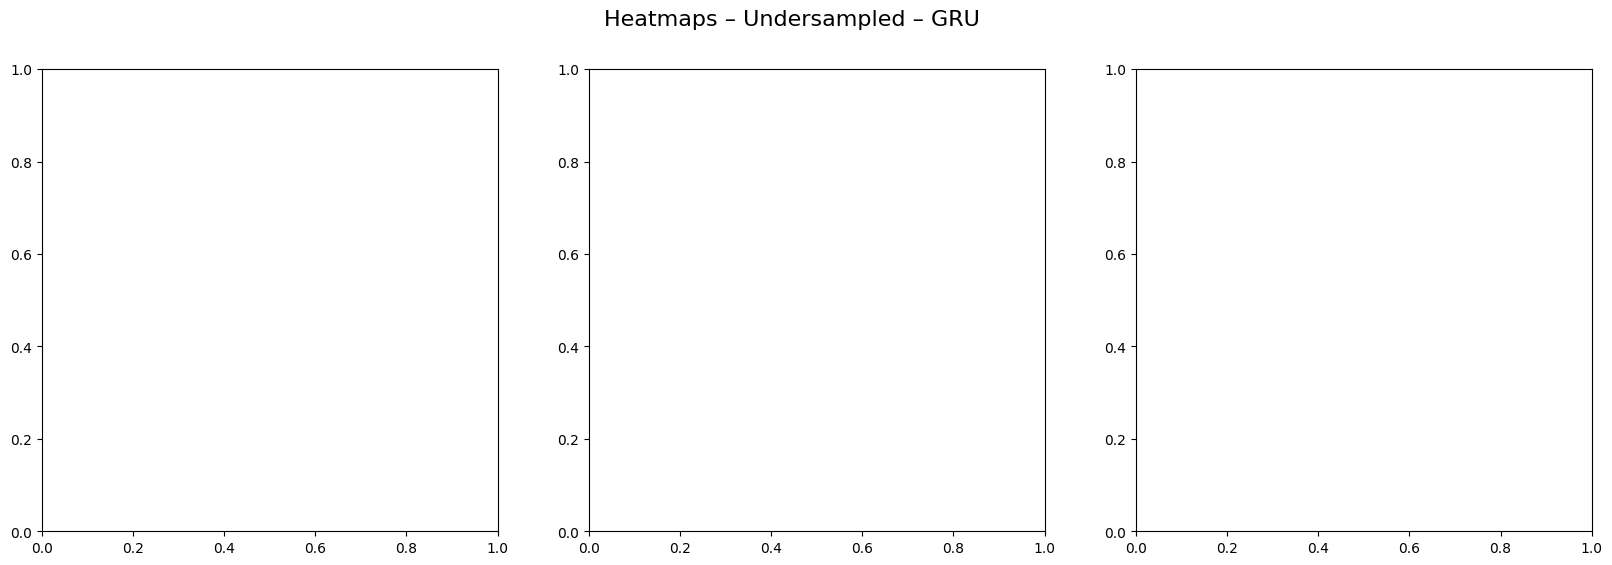

In [7]:
# === 6. Save & Visualize ===
OUTPUT_FILE = os.path.join(DATA_DIR, 'predictions_gpu_optimized.csv')
res_df = pd.DataFrame(results_all)
res_df.to_csv(OUTPUT_FILE, index=False)
res_df[['Sampling','Window']] = res_df['Model'].str.extract(r'(\d+h|\d+min)\|win=(\d+)')
res_df['Window'] = res_df['Window'].astype(int)
res_df['Method'] = res_df['Model'].apply(lambda m:
        'SMOTE' if 'SMOTE' in m else
        'Undersampled' if 'Under' in m else
        'ClassWeight' if 'ClassWeight' in m else
        'Original')
res_df['Type'] = res_df['Model'].apply(lambda m: 'GRU' if 'GRU' in m else 'LSTM' if 'LSTM' in m else 'Transformer')

metrics = ['Accuracy', 'F1_Score', 'AUC']
cmaps = ['Blues', 'Greens', 'Oranges']

for method in res_df.Method.unique():
    df_m = res_df[res_df.Method == method]
    for model_type in ['GRU', 'LSTM', 'Transformer']:
        df_sub = df_m[df_m['Type'] == model_type]
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f"Heatmaps – {method} – {model_type}", fontsize=16)
        for i, metric in enumerate(metrics):
            pivot = df_sub.pivot_table(index='Window', columns='Sampling', values=metric, aggfunc='mean')
            sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmaps[i], ax=axes[i])
            axes[i].set_title(metric)
            axes[i].set_xlabel('Sampling')
            axes[i].set_ylabel('Window' if i == 0 else '')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# === Tampilkan Hasil dalam Tabel Komparatif ===
display(res_df[['Model', 'Type', 'Method', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC',
                'TrainingTime', 'TrainableParams', 'ModelSize_MB', 'GPU_Memory_MB']].round(4))